# Example 1: HiggsML Challenge with Convolutional Networks

In [1]:
from pathlib import Path
import urllib.request
import pprint as pp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
dataset_file_path = Path('./data/dataset.csv.gz')

## Download dataset

In [5]:
if not dataset_file_path.exists():
    urllib.request.urlretrieve(
        url='https://opendata.cern.ch/record/328/files/atlas-higgs-challenge-2014-v2.csv.gz',
        filename=dataset_file_path,
    )

## Load the compressed dataset file into a DataFrame

In [6]:
df = pd.read_csv(dataset_file_path)

In [7]:
df.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label,KaggleSet,KaggleWeight
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2.150,0.444,46.062,1.24,-2.475,113.497,0.000814,s,t,0.002653
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,0.725,1.158,-999.000,-999.00,-999.000,46.226,0.681042,b,t,2.233584
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,2.053,-2.028,-999.000,-999.00,-999.000,44.251,0.715742,b,t,2.347389
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,1.660654,b,t,5.446378
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,1.904263,b,t,6.245333


In [8]:
df.columns

Index(['EventId', 'DER_mass_MMC', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi',
       'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi',
       'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt',
       'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_jet_all_pt',
       'Weight', 'Label', 'KaggleSet', 'KaggleWeight'],
      dtype='object')

Use the training set for visualization

In [ ]:
df = df[df['KaggleSet'] == 't']

In [81]:
np.unique(df['Label'], return_counts=True)

(array(['b', 's'], dtype=object), array([164333,  85667]))

In [ ]:
df.insert(
    loc=len(df.columns),
    column='is_sig',
    value=(df['Label'] == 's'),
)

In [ ]:
df.insert(
    loc=len(df.columns),
    column='is_bkg',
    value=(df['Label'] == 'b'),
)

In [83]:
num_bkg_events = df['KaggleWeight'][df['is_bkg']].sum()
num_sig_events = df['KaggleWeight'][df['is_sig']].sum()

In [88]:
print(f'Signal : Background = {num_sig_events:_.0f} : {num_bkg_events:_.0f}')

Signal : Background = 692 : 411_000


## Visualize dataset

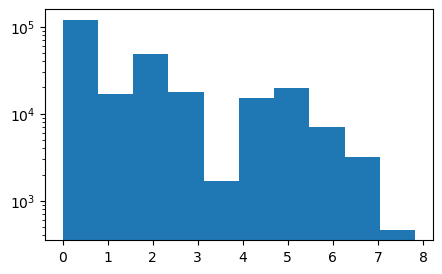

In [12]:
event_weight = df['KaggleWeight']
fig, ax = plt.subplots(figsize=(5, 3), ncols=1, nrows=1)
ax.hist(event_weight)
ax.set_yscale('log')

In [25]:
np.ceil(3.6)

np.float64(4.0)

In [69]:
def plot_hist(
    df: pd.DataFrame,
    column_list: list[str],
    yscale_log_column_list: list[str] = [],
    density=True,
    nrows: int = 1,
):
    ncols = int(np.ceil(len(column_list) / nrows))
    fig, axarr = plt.subplots(figsize=(5 * ncols, 3 * nrows), ncols=ncols, nrows=nrows)
    
    for ax, column in zip(axarr.ravel(), column_list):
        mask = (df[column] != -999).to_numpy(np.bool)
        
        ax.hist(
            x=[
                df[column][mask & df.is_bkg],
                df[column][mask & df.is_sig],
            ], 
            label=[
                'Background',
                'Signal',
            ],
            weights=[
                df['KaggleWeight'][mask & df.is_bkg],
                df['KaggleWeight'][mask & df.is_sig],
            ],    
            histtype='step',
            lw=2,
            density=density,
        )
        ax.set_xlabel(column)
        ax.set_ylabel('Events')
        ax.legend()
        ax.legend(loc='upper right')

        if column in yscale_log_column_list:
            ax.set_yscale('log')
            ax.set_ylim(None, 10 * ax.get_ylim()[1])
        else:
            ax.set_ylim(None, 2 * ax.get_ylim()[1])

    for idx in range(len(column_list), len(axarr.ravel())):
        axarr.ravel()[idx].axis('off')
    
    return fig

### Primitive Features

#### Tau

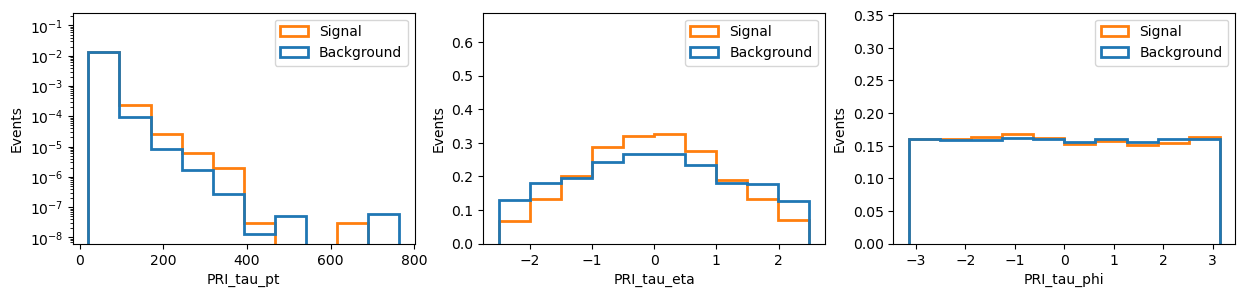

In [70]:
fig = plot_hist(df, ['PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi'], yscale_log_column_list=['PRI_tau_pt'])

#### (Charged) Lepton: electron or muon

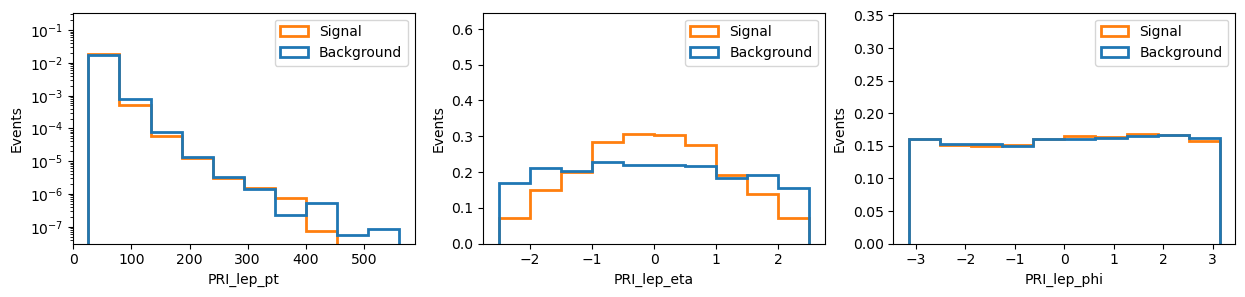

In [71]:
fig = plot_hist(df, ['PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi'], yscale_log_column_list=['PRI_lep_pt'])

#### Missing Transverse Momentum

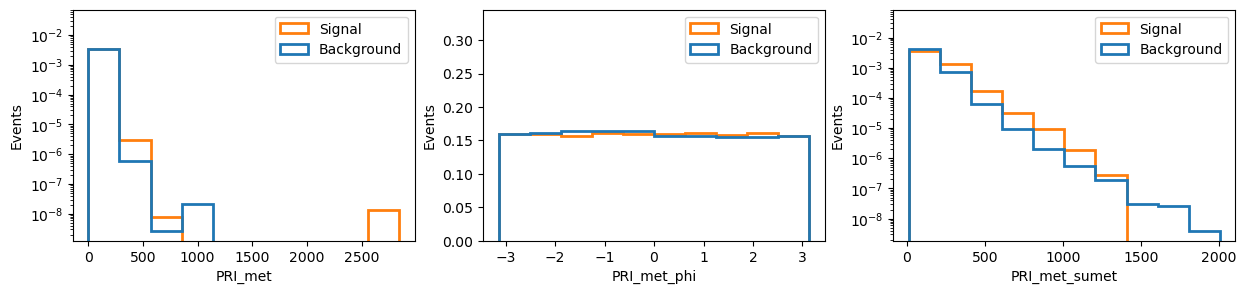

In [72]:
fig = plot_hist(df, ['PRI_met', 'PRI_met_phi', 'PRI_met_sumet'], yscale_log_column_list=['PRI_met', 'PRI_met_sumet'])

#### Jet

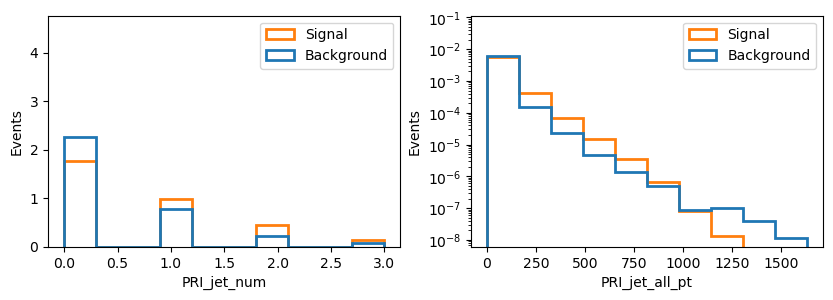

In [73]:
fig = plot_hist(df, ['PRI_jet_num', 'PRI_jet_all_pt'], yscale_log_column_list=['PRI_jet_all_pt'])

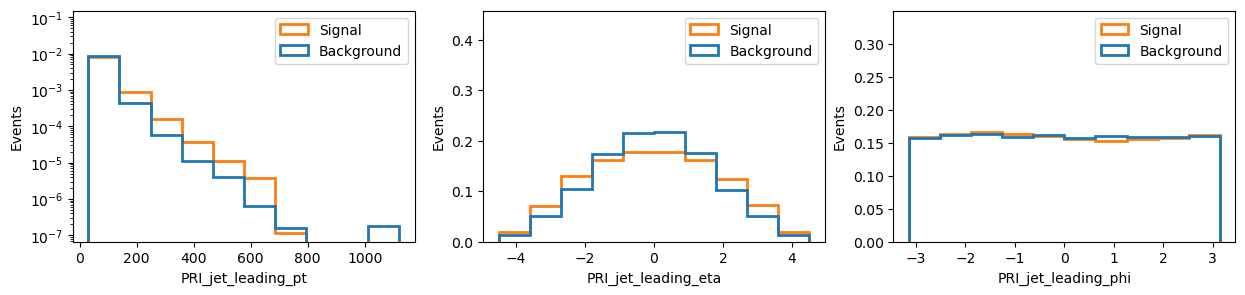

In [74]:
fig = plot_hist(df, ['PRI_jet_leading_pt', 'PRI_jet_leading_eta', 'PRI_jet_leading_phi'], yscale_log_column_list=['PRI_jet_leading_pt'])

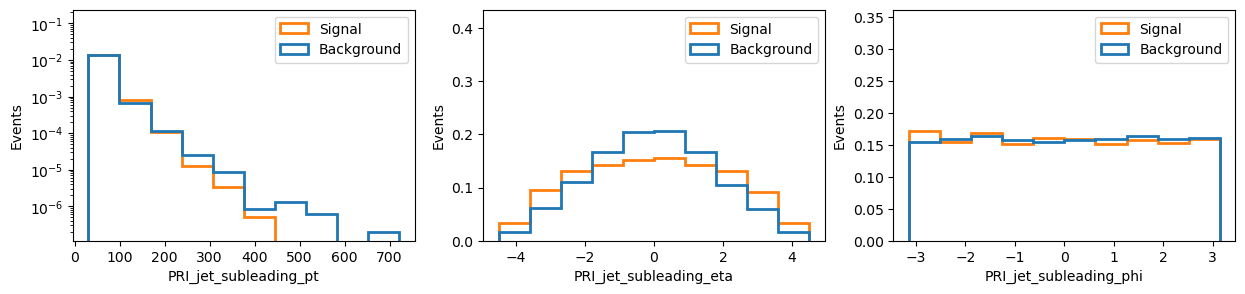

In [75]:
fig = plot_hist(df, ['PRI_jet_subleading_pt', 'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi'], yscale_log_column_list=['PRI_jet_subleading_pt'])

### Derived Features

In [76]:
der_column_list = [
    column for column in df.columns
    if column.startswith('DER_')
]
pp.pprint(der_column_list)

['DER_mass_MMC',
 'DER_mass_transverse_met_lep',
 'DER_mass_vis',
 'DER_pt_h',
 'DER_deltaeta_jet_jet',
 'DER_mass_jet_jet',
 'DER_prodeta_jet_jet',
 'DER_deltar_tau_lep',
 'DER_pt_tot',
 'DER_sum_pt',
 'DER_pt_ratio_lep_tau',
 'DER_met_phi_centrality',
 'DER_lep_eta_centrality']


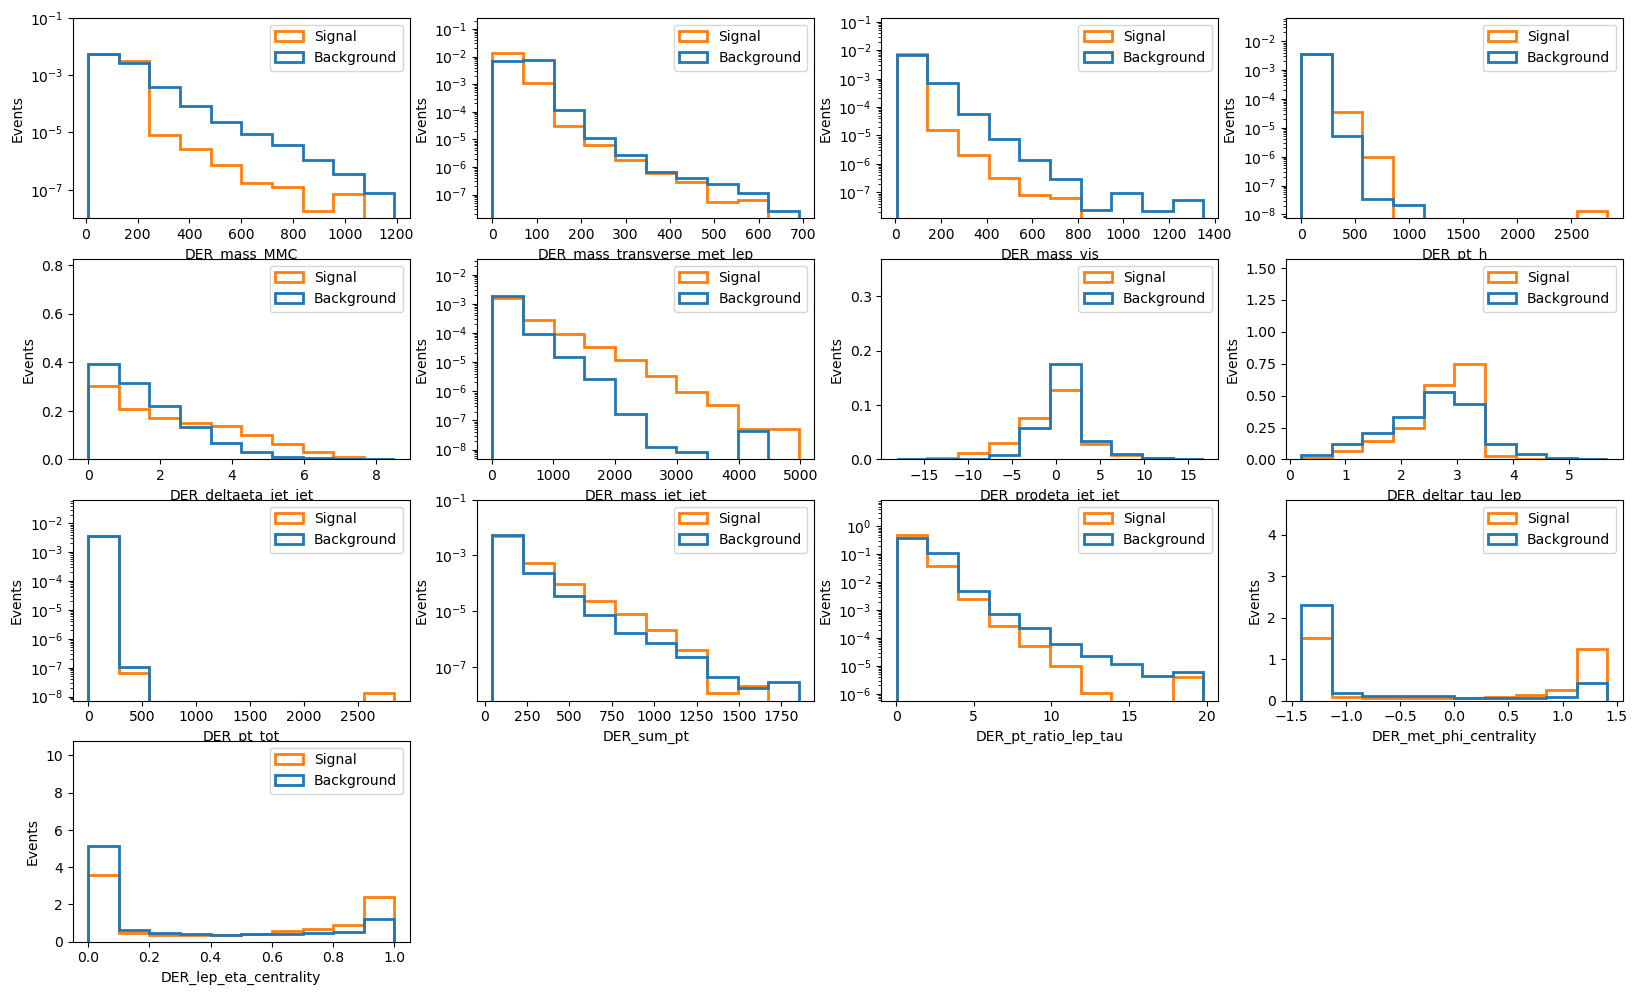

In [79]:
fig = plot_hist(
    df=df,
    column_list=der_column_list,
    yscale_log_column_list=[
        'DER_mass_MMC',
        'DER_mass_transverse_met_lep',
        'DER_mass_vis',
        'DER_pt_h',
        'DER_mass_jet_jet',
        'DER_pt_tot',
        'DER_sum_pt',
        'DER_pt_ratio_lep_tau',
    ],
    nrows=4,
)